In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk

plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["axes.grid"] = True

Normal ECG shape: (10000, 12)
          I        II       III       aVR       aVL       aVF        V1  \
0  1.071910  0.576477  0.519198  0.643179  1.044018  0.458228  1.142127   
1  1.066573  0.575419  0.520492  0.644388  1.038646  0.457862  1.139534   
2  1.056031  0.573709  0.523713  0.648218  1.027716  0.457829  1.135751   
3  1.040158  0.571286  0.528901  0.654681  1.011127  0.458141  1.130710   
4  1.018974  0.568111  0.536045  0.663721  0.988934  0.458801  1.124375   

         V2        V3        V4        V5        V6  
0  1.074754  1.092123  1.161153  1.179095  0.991971  
1  1.072269  1.085883  1.154904  1.174140  0.989325  
2  1.067784  1.074428  1.143447  1.164513  0.983720  
3  1.061204  1.057724  1.126737  1.150134  0.975142  
4  1.052493  1.035861  1.104849  1.131052  0.963667  


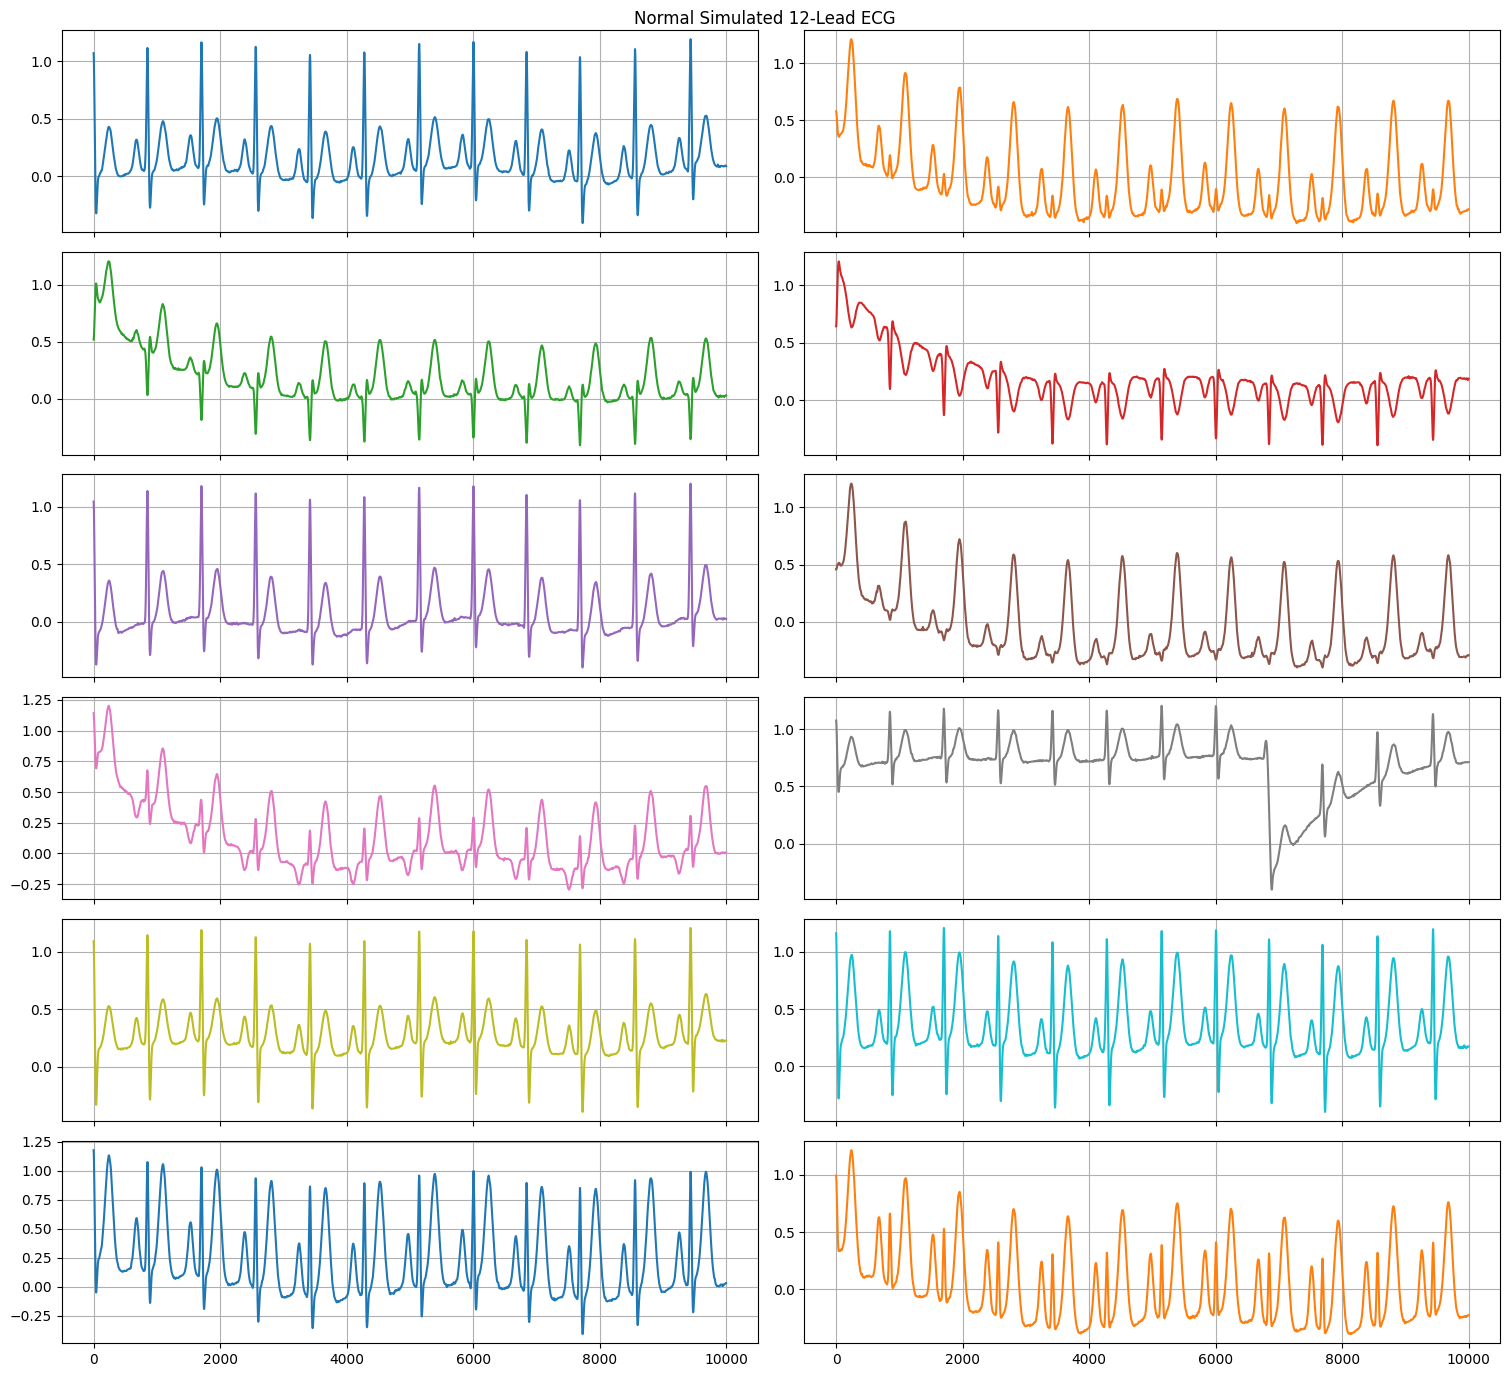

In [2]:
# Generate Normal Multi-Lead ECG

# Simulate 10 seconds of normal 12-lead ECG
ecg12_normal = nk.ecg_simulate(
    duration=10,
    method="multileads"
)

print("Normal ECG shape:", ecg12_normal.shape)
print(ecg12_normal.head())

# Plot first 10,000 samples
ecg12_normal[0:10000].plot(
    subplots=True,
    layout=(6, 2),
    figsize=(15, 14),
    sharex=True,
    legend=False,
    title="Normal Simulated 12-Lead ECG"
)

plt.tight_layout()
plt.show()

In [3]:
# t = starting positions (radians / phase positions)
ti = np.array((-70, -15, 0, 15, 100))

# a = amplitudes of waveform components
ai = np.array((1.2, -5, 30, -7.5, 0.75))

# b = widths of waveform components
bi = np.array((0.25, 0.1, 0.1, 0.1, 0.4))

print("\nDefault Parameters")
print("ti =", ti)
print("ai =", ai)
print("bi =", bi)


Default Parameters
ti = [-70 -15   0  15 100]
ai = [ 1.2  -5.   30.   -7.5   0.75]
bi = [0.25 0.1  0.1  0.1  0.4 ]


In [4]:
# Add Random Noise to Parameters to Simulate Abnormal Leads

np.random.seed(42)  # reproducibility

ti_abnormal = np.random.normal(
    loc=ti,
    scale=np.ones(5) * 3
)

ai_abnormal = np.random.normal(
    loc=ai,
    scale=np.abs(ai / 5)
)

bi_abnormal = np.random.normal(
    loc=bi,
    scale=np.abs(bi / 5)
)

print("\nAbnormal Parameters")
print("ti =", ti_abnormal)
print("ai =", ai_abnormal)
print("bi =", bi_abnormal)



Abnormal Parameters
ti = [-68.50985754 -15.4147929    1.94306561  19.56908957  99.29753988]
ai = [ 1.14380713 -3.42078718 34.60460837 -8.20421158  0.83138401]
bi = [0.22682912 0.0906854  0.10483925 0.0617344  0.26200657]



Abnormal ECG shape: (10000, 12)


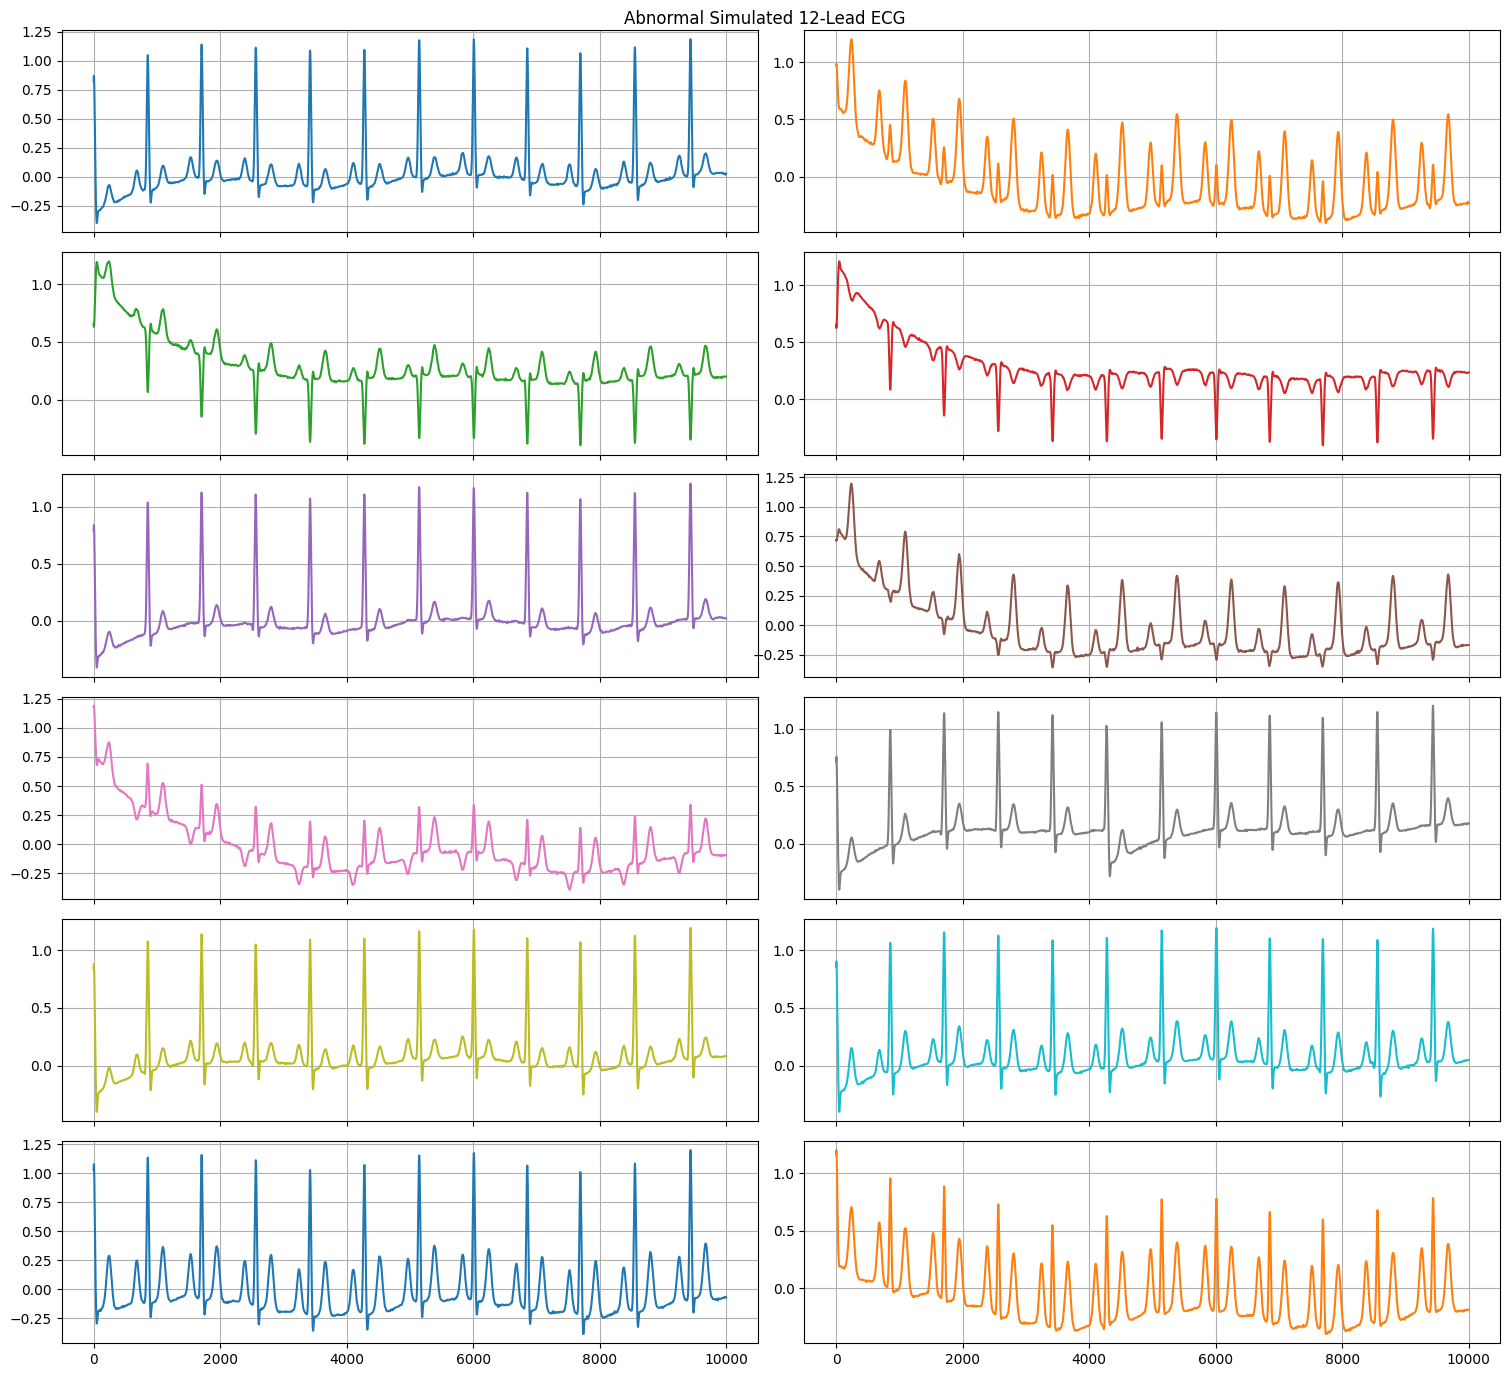

In [5]:
# Generate Abnormal Multi-Lead ECG

ecg12_abnormal = nk.ecg_simulate(
    duration=10,
    method="multileads",
    ti=ti_abnormal,
    ai=ai_abnormal,
    bi=bi_abnormal
)

print("\nAbnormal ECG shape:", ecg12_abnormal.shape)

# Plot first 10,000 samples
ecg12_abnormal[0:10000].plot(
    subplots=True,
    layout=(6, 2),
    figsize=(15, 14),
    sharex=True,
    legend=False,
    title="Abnormal Simulated 12-Lead ECG"
)

plt.tight_layout()
plt.show()


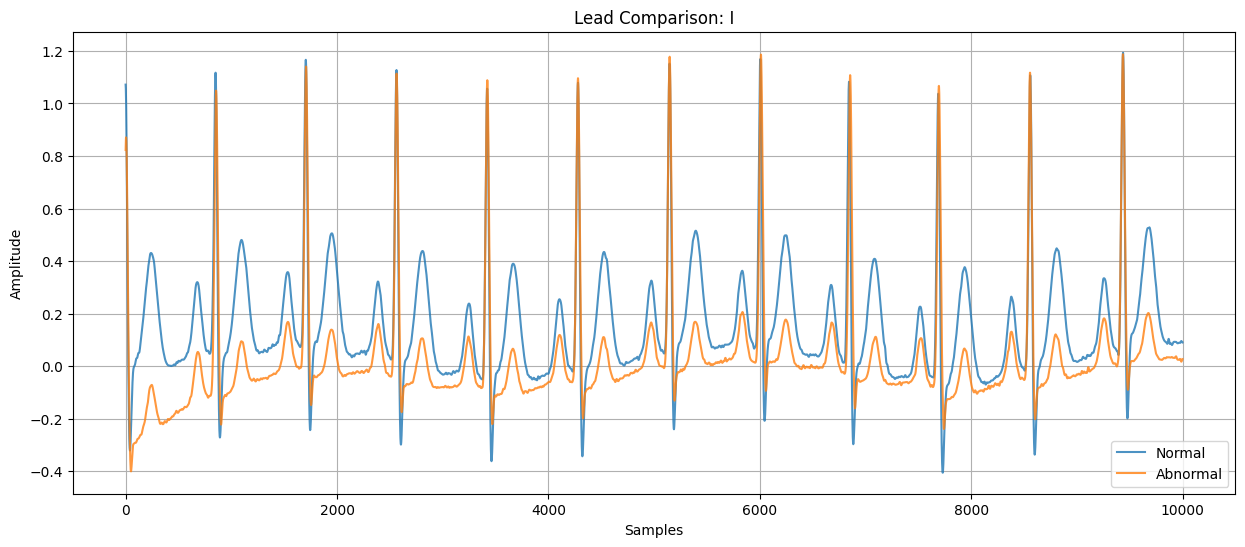

In [6]:
# Compare to One Lead

lead_name = ecg12_normal.columns[0]

plt.figure(figsize=(15,6))
plt.plot(ecg12_normal[lead_name], label="Normal", alpha=0.8)
plt.plot(ecg12_abnormal[lead_name], label="Abnormal", alpha=0.8)
plt.title(f"Lead Comparison: {lead_name}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [7]:
# Explanation

explanation = pd.DataFrame({
    "Parameter": ["ti", "ai", "bi"],
    "Meaning": [
        "Starting position of each wave along cardiac cycle",
        "Amplitude of each wave/spike",
        "Width of each wave"
    ],
    "Effect on ECG": [
        "Moves P/QRS/T waves earlier or later",
        "Makes waves taller or smaller",
        "Makes waves narrower or broader"
    ]
})

print("\nParameter Explanation")
display(explanation)


Parameter Explanation


,Parameter,Meaning,Effect on ECG
0,ti,Starting position of each wave along cardiac c...,Moves P/QRS/T waves earlier or later
1,ai,Amplitude of each wave/spike,Makes waves taller or smaller
2,bi,Width of each wave,Makes waves narrower or broader
